In [31]:
import thinkbayes

class Beta(object):

    def __init__(self, alpha=1, beta=1):
        self.alpha = alpha
        self.beta = beta

    def Update(self, data):
        heads, tails = data
        self.alpha += heads
        self.beta += tails

    def Mean(self):
        return float(self.alpha / (self.alpha + self.beta))
    
    def EvalPdf(self, x):
        return x**(self.alpha - 1) * (1-x)**(self.beta - 1)


In [32]:
beta = thinkbayes.Beta()
beta.Update((140, 110))

print(beta.Mean())

print(beta.EvalPdf(0.56))


0.5595238095238095
3.358289985239045e-75


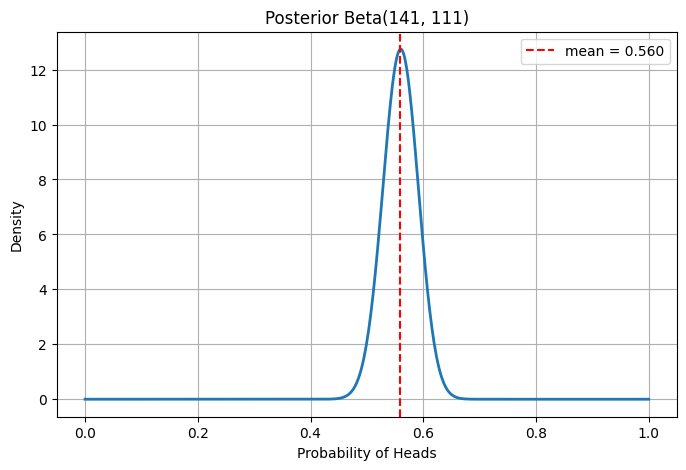

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# データ
heads = 140
tails = 110

# 事前分布 Beta(1,1)
alpha = 1
beta_param = 1

# Update
alpha += heads
beta_param += tails

# x軸
x = np.linspace(0, 1, 500)

# PDF
pdf = beta.pdf(x, alpha, beta_param)

# 描画
plt.figure(figsize=(8,5))
plt.plot(x, pdf, lw=2)
plt.xlabel("Probability of Heads")
plt.ylabel("Density")
plt.title(f"Posterior Beta({alpha}, {beta_param})")
plt.grid(True)

# 平均
mean = alpha / (alpha + beta_param)
plt.axvline(mean, color="red", linestyle="--",
            label=f"mean = {mean:.3f}")

plt.legend()
plt.show()

### 共役事前確率 (conjugate prior)

In [34]:
import numpy as np
from scipy.stats import beta

a, b = 2, 5

x = np.linspace(0, 1, 100)
y = beta.pdf(x, a, b)

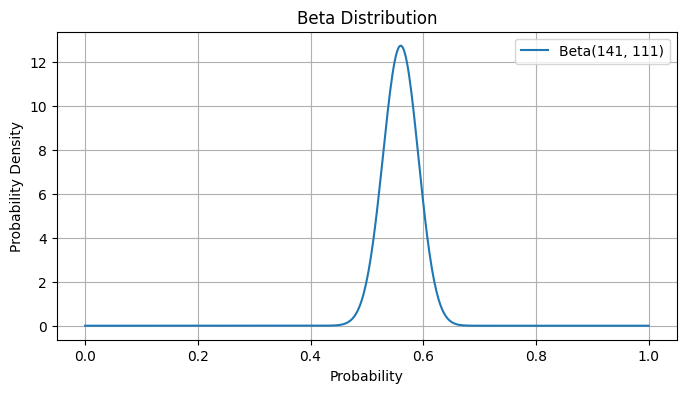

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# パラメータ
alpha = 141
beta_param = 111   # betaという名前は関数名とかぶるので別名にする

# x座標
x = np.linspace(0, 1, 500)

# 確率密度(PDF)
y = beta.pdf(x, alpha, beta_param)

# グラフ
plt.figure(figsize=(8, 4))
plt.plot(x, y, label=f'Beta({alpha}, {beta_param})')

plt.title("Beta Distribution")
plt.xlabel("Probability")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()

plt.show()

Beta
A Mean = 0.7381
B Mean = 0.6190

Pmf
A Mean = 0.7381
B Mean = 0.6190

A 95% CI = (0.595, 0.86)
B 95% CI = (0.47, 0.76)

A MAP = 0.75
B MAP = 0.625

Probability
P(A>B) = 0.8775

Difference
Mean = 0.1190
95% CI = (-0.07999999999999996, 0.31499999999999995)

Ratio
Mean = 1.2105
95% CI = (0.8897637795275589, 1.6363636363636365)


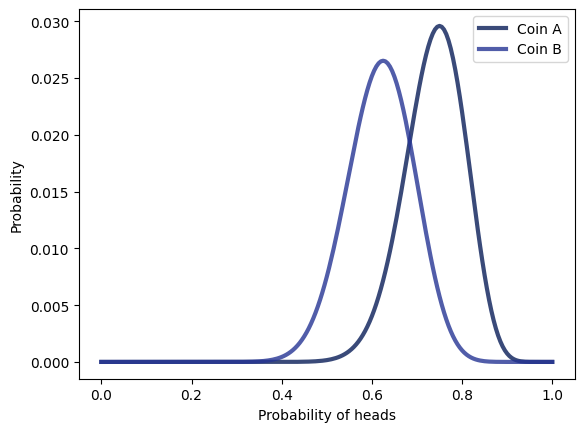

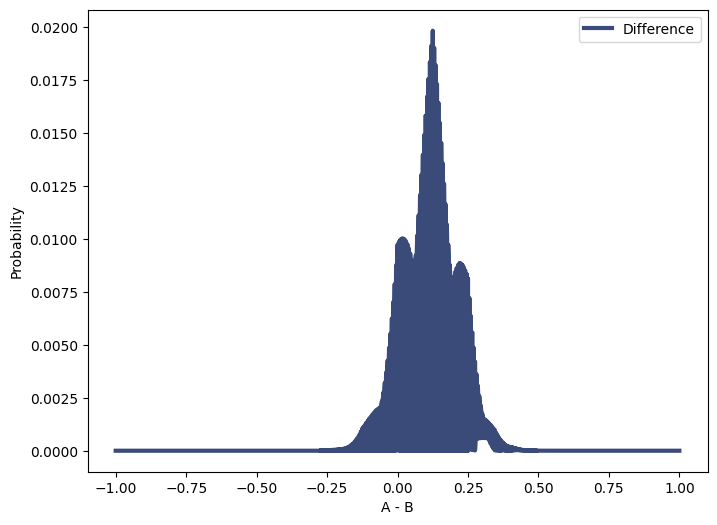

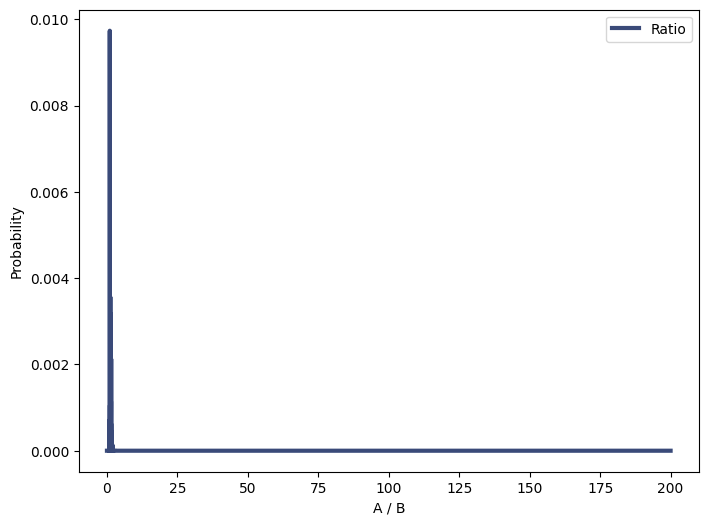

<Figure size 800x600 with 0 Axes>

In [39]:
"""
Beta → Pmf → Pmfの利用例
ThinkBayes2版
"""

from thinkbayes import Beta, Pmf, PmfProbGreater
from thinkplot import Plot, Show

# ==========================================================
# 補助関数
# ==========================================================

def DifferencePmf(pmf1, pmf2):
    """X-Y の分布"""
    pmf = Pmf()
    for x, px in pmf1.Items():
        for y, py in pmf2.Items():
            pmf.Incr(x - y, px * py)
    pmf.Normalize()
    return pmf


def RatioPmf(pmf1, pmf2):
    """X/Y の分布"""
    pmf = Pmf()
    for x, px in pmf1.Items():
        for y, py in pmf2.Items():
            if y != 0:
                pmf.Incr(x / y, px * py)
    pmf.Normalize()
    return pmf


# ==========================================================
# 1. ベイズ更新
# ==========================================================

coinA = Beta()
coinB = Beta()

# A : 30勝10敗
coinA.Update((30, 10))

# B : 25勝15敗
coinB.Update((25, 15))

print("=" * 60)
print("Beta")
print("=" * 60)

print(f"A Mean = {coinA.Mean():.4f}")
print(f"B Mean = {coinB.Mean():.4f}")

# ==========================================================
# 2. Beta → Pmf
# ==========================================================

pmfA = coinA.MakePmf(201)
pmfB = coinB.MakePmf(201)

print()
print("=" * 60)
print("Pmf")
print("=" * 60)

print(f"A Mean = {pmfA.Mean():.4f}")
print(f"B Mean = {pmfB.Mean():.4f}")

print()

print("A 95% CI =", pmfA.CredibleInterval(95))
print("B 95% CI =", pmfB.CredibleInterval(95))

print()

print("A MAP =", pmfA.MaximumLikelihood())
print("B MAP =", pmfB.MaximumLikelihood())

# ==========================================================
# 3. A>B の確率
# ==========================================================

print()
print("=" * 60)
print("Probability")
print("=" * 60)

p = PmfProbGreater(pmfA, pmfB)

print(f"P(A>B) = {p:.4f}")

# ==========================================================
# 4. 差の分布
# ==========================================================

diff = DifferencePmf(pmfA, pmfB)

print()
print("=" * 60)
print("Difference")
print("=" * 60)

print(f"Mean = {diff.Mean():.4f}")
print("95% CI =", diff.CredibleInterval(95))

# ==========================================================
# 5. 比の分布
# ==========================================================

ratio = RatioPmf(pmfA, pmfB)

print()
print("=" * 60)
print("Ratio")
print("=" * 60)

print(f"Mean = {ratio.Mean():.4f}")
print("95% CI =", ratio.CredibleInterval(95))

# ==========================================================
# 6. グラフ
# ==========================================================

Plot(pmfA, label="Coin A")
Plot(pmfB, label="Coin B")
Show(xlabel="Probability of heads",
     ylabel="Probability",
     legend=True)

Plot(diff, label="Difference")
Show(xlabel="A - B",
     ylabel="Probability",
     legend=True)

Plot(ratio, label="Ratio")
Show(xlabel="A / B",
     ylabel="Probability",
     legend=True)
